<a href="https://colab.research.google.com/github/lalygiraudo/prueba-git/blob/main/clasificaci%C3%B3niris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# CLASIFICACIÓN CON IRIS
# ============================================================

# 1. IMPORTAR LIBRERÍAS
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# ============================================================
# 2. CARGAR EL DATASET
# ============================================================

iris = load_iris()

# Convertimos los datos a un DataFrame
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Agregamos la variable objetivo
df["especie"] = iris.target

# Mostrar las primeras filas
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),especie
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
# ============================================================
# 3. CONOCER EL DATASET
# ============================================================

print("Cantidad de filas y columnas:", df.shape)

print("\nColumnas:")
print(df.columns)

print("\nInformación del dataset:")
df.info()

print("\nEstadísticas:")
display(df.describe())

Cantidad de filas y columnas: (150, 5)

Columnas:
Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'especie'],
      dtype='object')

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   especie            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB

Estadísticas:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),especie
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [ ]:
# ============================================================
# 4. VER LA DISTRIBUCIÓN DE LAS CLASES
# ============================================================

print(df["especie"].value_counts())

# 0 = setosa
# 1 = versicolor
# 2 = virginica

especie
0    50
1    50
2    50
Name: count, dtype: int64


In [ ]:
# ============================================================
# 5. SEPARAR VARIABLES PREDICTORAS (X) Y OBJETIVO (y)
# ============================================================

# X = características que utilizaremos para predecir
X = df.drop("especie", axis=1)

# y = variable que queremos predecir
y = df["especie"]

print("Variables predictoras:")
display(X.head())

print("Variable objetivo:")
display(y.head())

Variables predictoras:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


Variable objetivo:


,especie
0,0
1,0
2,0
3,0
4,0


In [ ]:
# ============================================================
# 6. SEPARAR DATOS DE ENTRENAMIENTO Y PRUEBA
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (120, 4)
Datos de prueba: (30, 4)


In [ ]:
# ============================================================
# 7. ESTANDARIZAR LAS VARIABLES
# ============================================================

scaler = StandardScaler()

# El scaler aprende de los datos de entrenamiento
X_train_scaled = scaler.fit_transform(X_train)

# Aplicamos la misma transformación a los datos de prueba
X_test_scaled = scaler.transform(X_test)

print("Variables estandarizadas correctamente.")

Variables estandarizadas correctamente.


In [ ]:
# ============================================================
# 8. CREAR Y ENTRENAR EL MODELO
# ============================================================

modelo = LogisticRegression(
    max_iter=200,
    random_state=42
)

# Entrenamiento
modelo.fit(X_train_scaled, y_train)

print("Modelo de Regresión Logística entrenado correctamente.")

Modelo de Regresión Logística entrenado correctamente.


In [ ]:
# ============================================================
# 9. HACER PREDICCIONES
# ============================================================

y_pred = modelo.predict(X_test_scaled)

print("Predicciones:")
print(y_pred)

print("\nValores reales:")
print(y_test.values)

Predicciones:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 1 2 2 1 0 2 0]

Valores reales:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


In [ ]:
# ============================================================
# 10. EVALUAR EL MODELO
# ============================================================

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 2))

Accuracy: 0.93


In [ ]:
# ============================================================
# 11. MATRIZ DE CONFUSIÓN
# ============================================================

matriz = confusion_matrix(y_test, y_pred)

print("Matriz de confusión:")
print(matriz)

Matriz de confusión:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


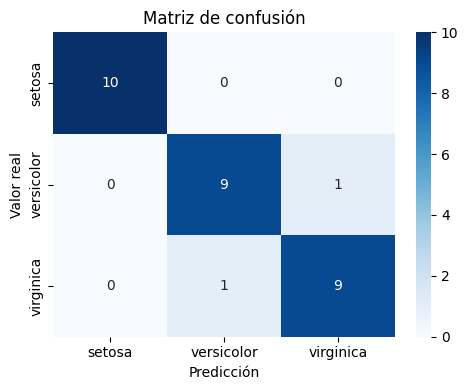

In [ ]:
import seaborn as sns

plt.figure(figsize=(5, 4))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de confusión")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 12. REPORTE DE CLASIFICACIÓN
# ============================================================

print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [ ]:
# ============================================================
# 13. PREDECIR UN NUEVO EJEMPLO
# ============================================================

nuevo_iris = [[
    5.1,   # largo del sépalo
    3.5,   # ancho del sépalo
    1.4,   # largo del pétalo
    0.2    # ancho del pétalo
]]

# IMPORTANTE:
# Primero debemos estandarizar el nuevo dato
nuevo_iris_scaled = scaler.transform(nuevo_iris)

# Hacer la predicción
prediccion = modelo.predict(nuevo_iris_scaled)

print("Clase predicha:", prediccion[0])
print("Especie predicha:", iris.target_names[prediccion[0]])

Clase predicha: 0
Especie predicha: setosa


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
# ============================================================
# 14. PROBABILIDADES DE LA PREDICCIÓN
# ============================================================

probabilidades = modelo.predict_proba(nuevo_iris_scaled)

for especie, probabilidad in zip(iris.target_names, probabilidades[0]):
    print(f"{especie}: {probabilidad:.2%}")

setosa: 98.08%
versicolor: 1.92%
virginica: 0.00%


Calcula una probabilidad para cada clase y elige la de mayor probabilidad.